## SubGraph
### Keeping routing intent in LangGraph state

In [28]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv
from langchain_ollama import ChatOllama

load_dotenv("./env")

google_api_key = os.getenv("GOOGLE_API_KEY")
openai_api_key = os.getenv("OPENAI_API_KEY")

google_llm = ChatGoogleGenerativeAI(
    temperature=0, 
    model="gemini-2.5-flash", 
    api_key=google_api_key,
    max_tokens=200
)

openai_llm = ChatOpenAI(
    temperature=0, 
    model="gpt-5-mini", 
    api_key=openai_api_key
)

ollama_llm = ChatOllama(
    model="llama3.1:latest",
    temperature=0
)

# google_llm.invoke("what is 2+2").content

In [29]:
# Basic LangGraph imports

from langgraph.graph import StateGraph, START, END, MessagesState
from IPython.display import display, Image
from pydantic import BaseModel, Field
from typing import Literal, List
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.checkpoint.memory import MemorySaver

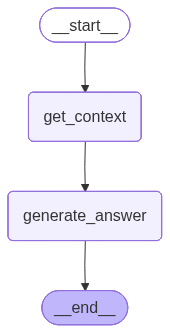

In [30]:
# RAG SubGraph

class RagState(MessagesState):
    pass

def get_context(state: MessagesState):
    pass

def generate_answer(state: MessagesState):
    pass

rag_builder = StateGraph(RagState)

rag_builder.add_node("get_context", get_context)
rag_builder.add_node("generate_answer", generate_answer)

rag_builder.add_edge(START, "get_context")
rag_builder.add_edge("get_context", "generate_answer")
rag_builder.add_edge("generate_answer", END)

rag_graph = rag_builder.compile()


display(Image(rag_graph.get_graph().draw_mermaid_png()))


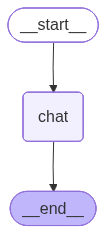

In [31]:
# Normal chat SubGraph

class ChatState(MessagesState):
    pass

def chat(state: MessagesState):
    res = openai_llm.invoke(state["messages"])
    return {"messages": res}

chat_builder = StateGraph(ChatState)

chat_builder.add_node("chat", chat)

chat_builder.add_edge(START, "chat")
chat_builder.add_edge("chat", END)

chat_graph = chat_builder.compile()

display(Image(chat_graph.get_graph().draw_mermaid_png()))



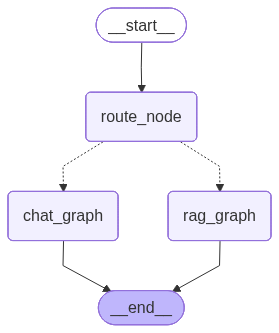

In [32]:
# RAG Parentgraph build


class MainState(MessagesState):
    intent_history: List[dict] = Field(default_factory=list)
    pass


class RouteIntent(BaseModel):
    is_rag: bool = Field(description="True if the user is asking about specific document details, policies, storage limits, accounts, or specs. False for general chit-chat.")


def route_node(state: MessagesState):
    last_message = state["messages"][-1].content
    structured_llm = openai_llm.with_structured_output(RouteIntent)
    
    decision = structured_llm.invoke(last_message)
    
    log_record = {
        "user_query": last_message,
        "is_rag": decision.is_rag
    }

    return {"intent_history": [log_record]}


def find_intent_edge(state: MainState) -> Literal["rag_graph", "chat_graph"]:
    decision = state['intent_history'][-1]
    if decision['is_rag']:
        return "rag_graph"
    return "chat_graph"


main_builder = StateGraph(MainState)


main_builder.add_node("route_node", route_node)
main_builder.add_node("rag_graph", rag_graph)
main_builder.add_node("chat_graph", chat_graph)

main_builder.add_edge(START, "route_node")
main_builder.add_conditional_edges("route_node", find_intent_edge)
main_builder.add_edge("rag_graph", END)
main_builder.add_edge("chat_graph", END)

main_graph = main_builder.compile(checkpointer=MemorySaver())

display(Image(main_graph.get_graph().draw_mermaid_png()))


In [33]:
config = {"configurable": {"thread_id": 1}}

res = main_graph.invoke({"messages": HumanMessage(content="how many holidays in my company?")}, config=config)
# res = main_graph.invoke({"messages": HumanMessage(content="What is IPL? in 1 line")}, config=config)
# res = main_graph.invoke({"messages": HumanMessage(content="Who is MS Dhoni? in 1 line.")}, config=config)

print(res)

{'messages': [HumanMessage(content='how many holidays in my company?', additional_kwargs={}, response_metadata={}, id='14279c36-dc73-42fb-99c8-da5a244cfdd7')], 'intent_history': [{'user_query': 'how many holidays in my company?', 'is_rag': True}]}


In [34]:
config = {"configurable": {"thread_id": 1}}

current_state = main_graph.get_state(config=config)

current_state.values

{'messages': [HumanMessage(content='how many holidays in my company?', additional_kwargs={}, response_metadata={}, id='14279c36-dc73-42fb-99c8-da5a244cfdd7')],
 'intent_history': [{'user_query': 'how many holidays in my company?',
   'is_rag': True}]}

In [35]:
current_state_history = main_graph.get_state_history(config=config)

for item in current_state_history:
    for msg in item.values.get('messages'):
        msg.pretty_print()
    print("\n\n")

================================ Human Message =================================

how many holidays in my company?



================================ Human Message =================================

how many holidays in my company?



================================ Human Message =================================

how many holidays in my company?






